# Chapter 2 — Cutoff convergence of GaAs

Companion notebook to Chapter 2. We turn the raw energy-vs-cutoff sweeps
(`code/02-pseudopotentials/ecut*_conv.dat`) into convergence curves in
meV/atom, the unit that actually tells you whether a cutoff is good
enough. Requirements: `numpy`, `matplotlib`.

In [1]:
import numpy as np
from pathlib import Path

RY_TO_MEV = 13605.693
NAT = 2  # atoms per cell -> energies are reported per atom

d = Path('../code/02-pseudopotentials')
ew, Ew = np.loadtxt(d/'ecutwfc_conv.dat', skiprows=1, unpack=True)
er, Er = np.loadtxt(d/'ecutrho_conv.dat', skiprows=1, unpack=True)

# Convergence error per atom, relative to the densest (most converged) point.
dEw = np.abs(Ew - Ew[-1]) / NAT * RY_TO_MEV
dEr = np.abs(Er - Er[-1]) / NAT * RY_TO_MEV

print('ecutwfc (Ry)  |E-E_ref| (meV/atom)')
for x, y in zip(ew, dEw):
    print(f'  {x:5.0f}        {y:10.2f}')

ecutwfc (Ry)  |E-E_ref| (meV/atom)
     20           2312.57
     30             33.87
     40             17.58
     50              3.03
     60              2.11
     70              0.57
     80              0.00


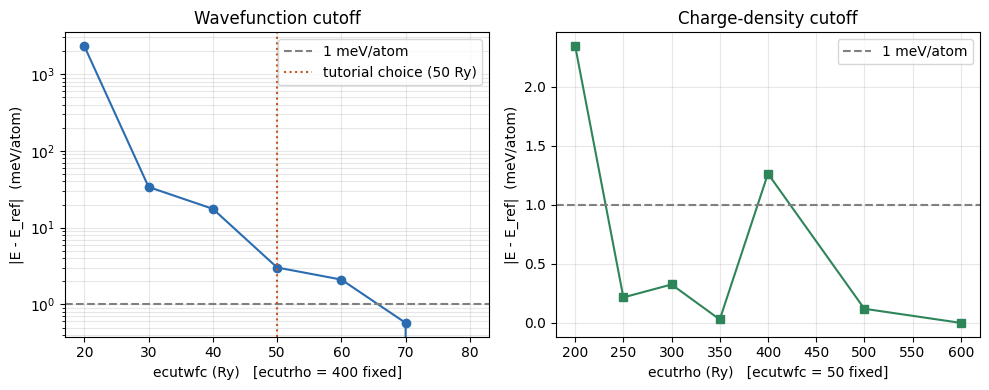

In [2]:
import matplotlib.pyplot as plt

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4))

a1.semilogy(ew, dEw, 'o-', color='#2b6cb0')
a1.axhline(1.0, ls='--', color='gray', label='1 meV/atom')
a1.axvline(50, ls=':', color='#c05621', label='tutorial choice (50 Ry)')
a1.set_xlabel('ecutwfc (Ry)   [ecutrho = 400 fixed]')
a1.set_ylabel('|E - E_ref|  (meV/atom)')
a1.set_title('Wavefunction cutoff')
a1.legend(); a1.grid(True, which='both', alpha=0.3)

a2.plot(er, dEr, 's-', color='#2f855a')
a2.axhline(1.0, ls='--', color='gray', label='1 meV/atom')
a2.set_xlabel('ecutrho (Ry)   [ecutwfc = 50 fixed]')
a2.set_ylabel('|E - E_ref|  (meV/atom)')
a2.set_title('Charge-density cutoff')
a2.legend(); a2.grid(True, alpha=0.3)

fig.tight_layout()
out_png = Path('../static/img/02-cutoff-convergence.png')
fig.savefig(out_png, dpi=120)
plt.show()

**What you see.** *Left:* the total energy falls monotonically as
`ecutwfc` grows — it is **variational**, so more plane waves can only
lower it. The curve is steep up to ~40 Ry and then flattens; our 50 Ry
choice sits a few meV/atom above the reference (fine for this tutorial;
push to ~70 Ry for sub-meV production work). *Right:* the energy is
**not** variational in `ecutrho` (changing the dense-grid sampling moves
the energy both ways) and is only weakly sensitive to it — it stays
within ~1 meV/atom across the whole range. `ecutrho` matters far more for
forces and stresses than for the total energy, which is why a generous
value is cheap insurance.

Compare with the cutoffs the pseudopotentials *suggest* in their headers
(Ga: 33/134 Ry, As: 20/103 Ry): the convergence study confirms that
comfortably exceeding the larger suggestion is enough.